# Final Project Proposal: Visualizations 3 and 4

Research question: **How do El Niño-like months reshape ocean and weather conditions across the Pacific?**

This notebook creates the two proposal visualizations assigned here:

- **Viz 3:** precipitation change during El Niño-like months (`pr`)
- **Viz 4:** cloud cover change during El Niño-like months (`clt`)

The El Niño-like months are defined from the CMIP6 `tos` sea surface temperature field using a simple Niño 3.4 index: average SST over 5S-5N, 170W-120W, monthly anomaly relative to the selected analysis period, and threshold of at least +0.5°C. This is appropriate for a proposal prototype because it is transparent and easy to explain, though the final project can refine it with 3-month running means if the team wants to align more closely with NOAA's operational ONI definition.

## 1. Setup

Run the install cell once if these packages are missing in your notebook environment.

In [26]:
# Uncomment if running in a fresh Colab / Jupyter environment.
#  !pip install --upgrade xarray zarr gcsfs cftime nc-time-axis matplotlib pandas numpy

In [27]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs

xr.set_options(display_style="html")
%matplotlib inline
%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "figure.figsize": (13, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

## 2. Load the CMIP6 catalog

This uses the same Google Cloud CMIP6 public Zarr catalog pattern from the class example.

In [28]:
catalog_url = "https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv"
df = pd.read_csv(catalog_url)
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


## 3. Pick a consistent model and variables

For the proposal, this notebook uses **NCAR CESM2, historical, r1i1p1f1** because it has the variables we need and matches the class loading example. Keeping one model/member avoids mixing grids and assumptions in an early static proposal.

In [29]:
MODEL = "CESM2"
MEMBER = "r1i1p1f1"
EXPERIMENT = "historical"
START_YEAR = "1950"
END_YEAR = "2014"

variables = {
    "tos": {"table_id": "Omon", "label": "Sea surface temperature", "units": "degC"},
    "pr": {"table_id": "Amon", "label": "Precipitation", "units": "mm/day"},
    "clt": {"table_id": "Amon", "label": "Total cloud cover", "units": "%"},
}

def find_store(variable_id, table_id):
    matches = df.query(
        "activity_id == 'CMIP' and "
        "source_id == @MODEL and "
        "experiment_id == @EXPERIMENT and "
        "member_id == @MEMBER and "
        "variable_id == @variable_id and "
        "table_id == @table_id"
    ).copy()
    if matches.empty:
        raise ValueError(f"No CMIP6 store found for {variable_id} / {table_id}.")
    return matches.sort_values("version", ascending=False).iloc[0]

store_rows = {var: find_store(var, info["table_id"]) for var, info in variables.items()}
pd.DataFrame(store_rows).T[["institution_id", "source_id", "experiment_id", "member_id", "table_id", "variable_id", "grid_label", "version", "zstore"]]

,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,version,zstore
tos,NCAR,CESM2,historical,r1i1p1f1,Omon,tos,gr,20190308,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...
pr,NCAR,CESM2,historical,r1i1p1f1,Amon,pr,gn,20190401,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...
clt,NCAR,CESM2,historical,r1i1p1f1,Amon,clt,gn,20190308,gs://cmip6/CMIP6/CMIP/NCAR/CESM2/historical/r1...


In [30]:
gcs = gcsfs.GCSFileSystem(token="anon")

def open_cmip6_zarr(row):
    return xr.open_zarr(gcs.get_mapper(row.zstore), consolidated=True)

ds_tos = open_cmip6_zarr(store_rows["tos"])
ds_pr = open_cmip6_zarr(store_rows["pr"])
ds_clt = open_cmip6_zarr(store_rows["clt"])

ds_tos, ds_pr, ds_clt

(<xarray.Dataset> Size: 513MB
 Dimensions:    (time: 1980, lat: 180, lon: 360, d2: 2)
 Coordinates:
   * time       (time) object 16kB 1850-01-15 13:00:00 ... 2014-12-15 12:00:00
   * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
   * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
     lat_bnds   (lat, d2) float64 3kB ...
     lon_bnds   (lon, d2) float64 6kB ...
     time_bnds  (time, d2) object 32kB ...
 Dimensions without coordinates: d2
 Data variables:
     tos        (time, lat, lon) float32 513MB ...
 Attributes: (12/46)
     Conventions:            CF-1.7 CMIP-6.2
     activity_id:            CMIP
     branch_method:          standard
     branch_time_in_child:   674885.0
     branch_time_in_parent:  219000.0
     case_id:                15
     ...                     ...
     table_id:               Omon
     tracking_id:            hdl:21.14100/113dbe36-4603-4625-acac-b06ce9c86222
     variable_id:            tos
 

## 4. Define El Niño-like months from tropical Pacific SST

Niño 3.4 box: 5S-5N and 170W-120W. CMIP longitudes are usually 0-360, so 170W-120W becomes 190E-240E.

In [31]:
def area_weighted_mean_latlon(da):
    """Area-weighted mean using cosine(latitude), useful when areacell is not needed."""
    weights = np.cos(np.deg2rad(da.lat))
    weights = weights / weights.mean()
    return da.weighted(weights).mean(("lat", "lon"))

tos = ds_tos["tos"].sel(time=slice(START_YEAR, END_YEAR))
nino34_sst = tos.sel(lat=slice(-5, 5), lon=slice(190, 240))
nino34 = area_weighted_mean_latlon(nino34_sst)

# Monthly anomaly: remove the average seasonal cycle before thresholding.
nino34_anom = nino34.groupby("time.month") - nino34.groupby("time.month").mean("time")
nino34_anom = nino34_anom.load()

def year_month_labels(time_coord):
    return xr.DataArray(time_coord.dt.strftime("%Y-%m").values, coords={"time": time_coord}, dims=("time",))

nino34_anom = nino34_anom.assign_coords(year_month=year_month_labels(nino34_anom.time))

el_nino_keys = nino34_anom.where(nino34_anom >= 0.5, drop=True).year_month.values
la_nina_keys = nino34_anom.where(nino34_anom <= -0.5, drop=True).year_month.values
neutral_keys = nino34_anom.where(abs(nino34_anom) < 0.5, drop=True).year_month.values

print(f"El Niño-like months: {len(el_nino_keys)}")
print(f"La Niña-like months: {len(la_nina_keys)}")
print(f"Neutral months: {len(neutral_keys)}")

El Niño-like months: 283
La Niña-like months: 282
Neutral months: 215


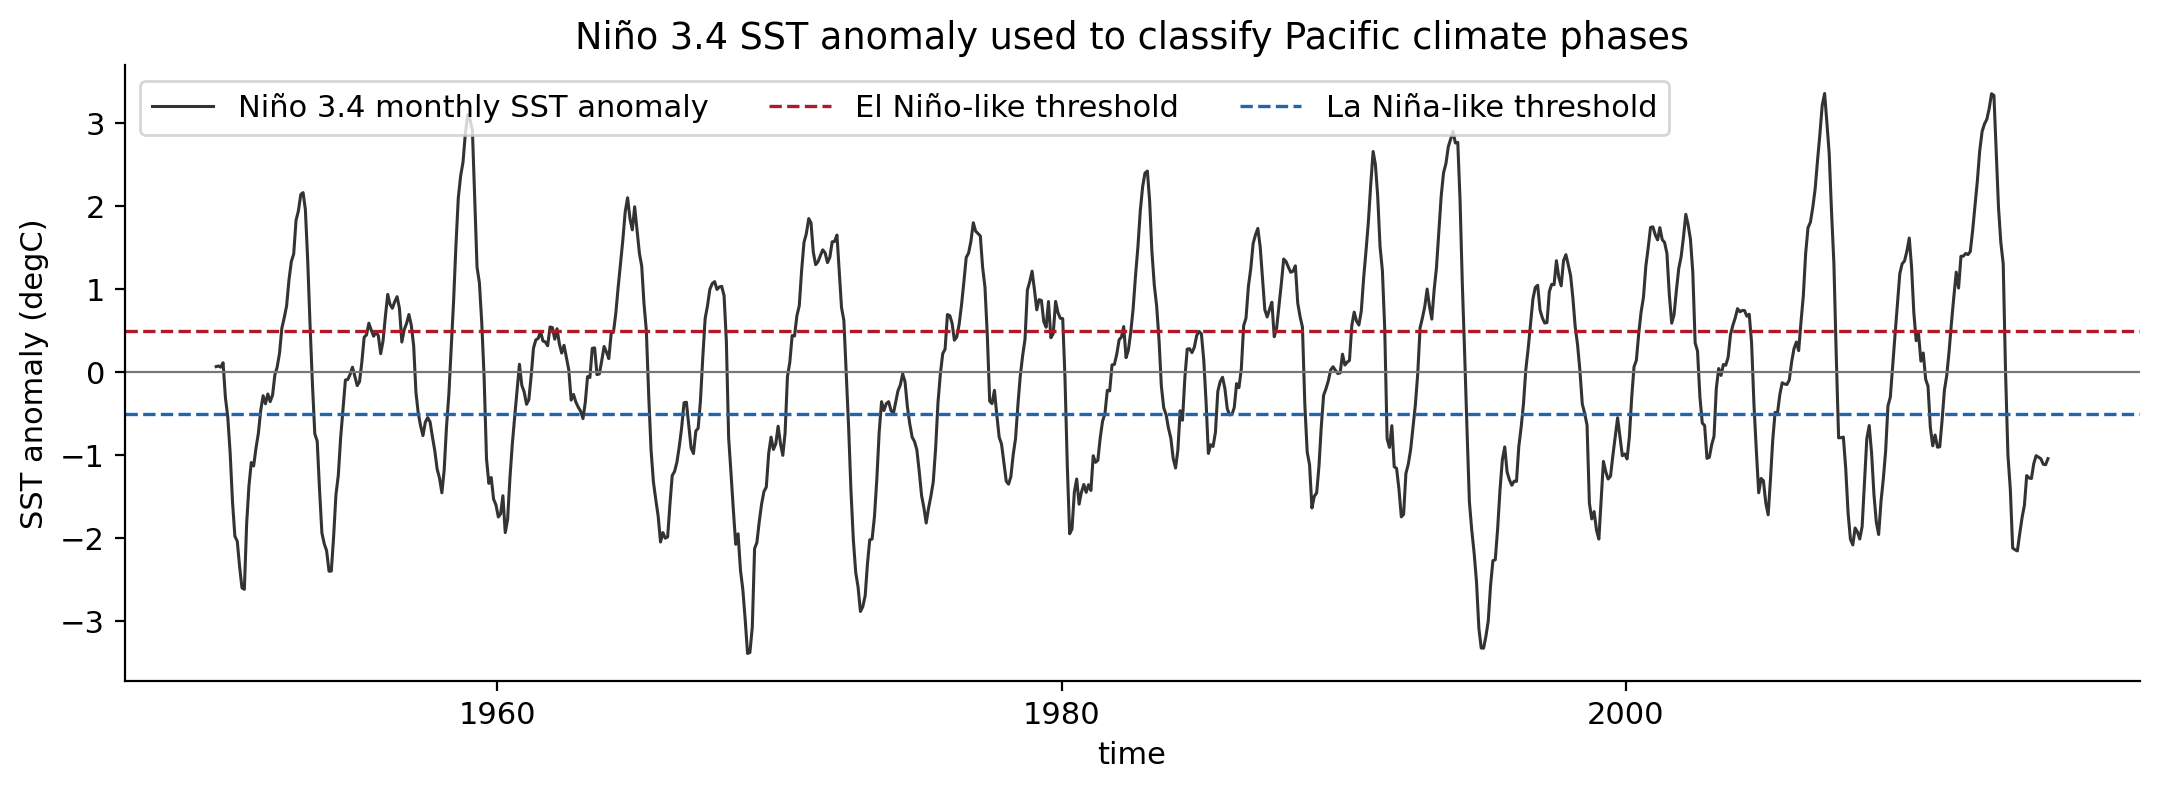

In [32]:
fig, ax = plt.subplots(figsize=(13, 4))
nino34_anom.plot(ax=ax, color="#333333", lw=1.1, label="Niño 3.4 monthly SST anomaly")
ax.axhline(0.5, color="#b2182b", lw=1.2, ls="--", label="El Niño-like threshold")
ax.axhline(-0.5, color="#2166ac", lw=1.2, ls="--", label="La Niña-like threshold")
ax.axhline(0, color="#777777", lw=0.8)
ax.set_title("Niño 3.4 SST anomaly used to classify Pacific climate phases")
ax.set_ylabel("SST anomaly (degC)")
ax.legend(loc="upper left", ncol=3)
plt.show()

## 5. Shared composite helpers

The maps below compare El Niño-like months against neutral months. This answers the proposal question more directly than raw averages because it shows the weather/cloud pattern associated with the warm Pacific phase.

In [33]:
def convert_units(da, variable_id):
    if variable_id == "pr":
        # CMIP6 precipitation is kg m-2 s-1, equivalent to mm/s for liquid water.
        return da * 86400
    return da

def composite_difference(ds, variable_id):
    da = convert_units(ds[variable_id].sel(time=slice(START_YEAR, END_YEAR)), variable_id)
    da = da.assign_coords(year_month=year_month_labels(da.time))
    el = da.where(da.year_month.isin(el_nino_keys), drop=True).mean("time")
    neutral = da.where(da.year_month.isin(neutral_keys), drop=True).mean("time")
    diff = (el - neutral).load()
    el = el.load()
    neutral = neutral.load()
    return el, neutral, diff

def pacific_view(da):
    # Focus on the Pacific basin for the story: 120E to 80W, about 50S to 50N.
    return da.sel(lon=slice(120, 280), lat=slice(-50, 50))

def plot_pacific_map(da, title, units, cmap, center_zero=True):
    data = pacific_view(da)
    fig, ax = plt.subplots(figsize=(13, 5.8))
    kwargs = {"ax": ax, "x": "lon", "y": "lat", "cmap": cmap, "cbar_kwargs": {"label": units}}
    if center_zero:
        vmax = float(np.nanpercentile(np.abs(data.values), 98))
        kwargs.update({"vmin": -vmax, "vmax": vmax})
    mesh = data.plot(**kwargs)
    ax.set_title(title)
    ax.set_xlabel("Longitude (degrees east)")
    ax.set_ylabel("Latitude")
    ax.axvspan(190, 240, ymin=(45/100), ymax=(55/100), facecolor="none", edgecolor="black", lw=1.5, hatch="///", alpha=0.9)
    ax.text(192, 8, "Niño 3.4", color="black", fontsize=10, weight="bold")
    plt.show()
    return mesh

## Viz 3. Precipitation change during El Niño-like months

Variable: `pr`, precipitation. Units are converted from kg m-2 s-1 to mm/day.

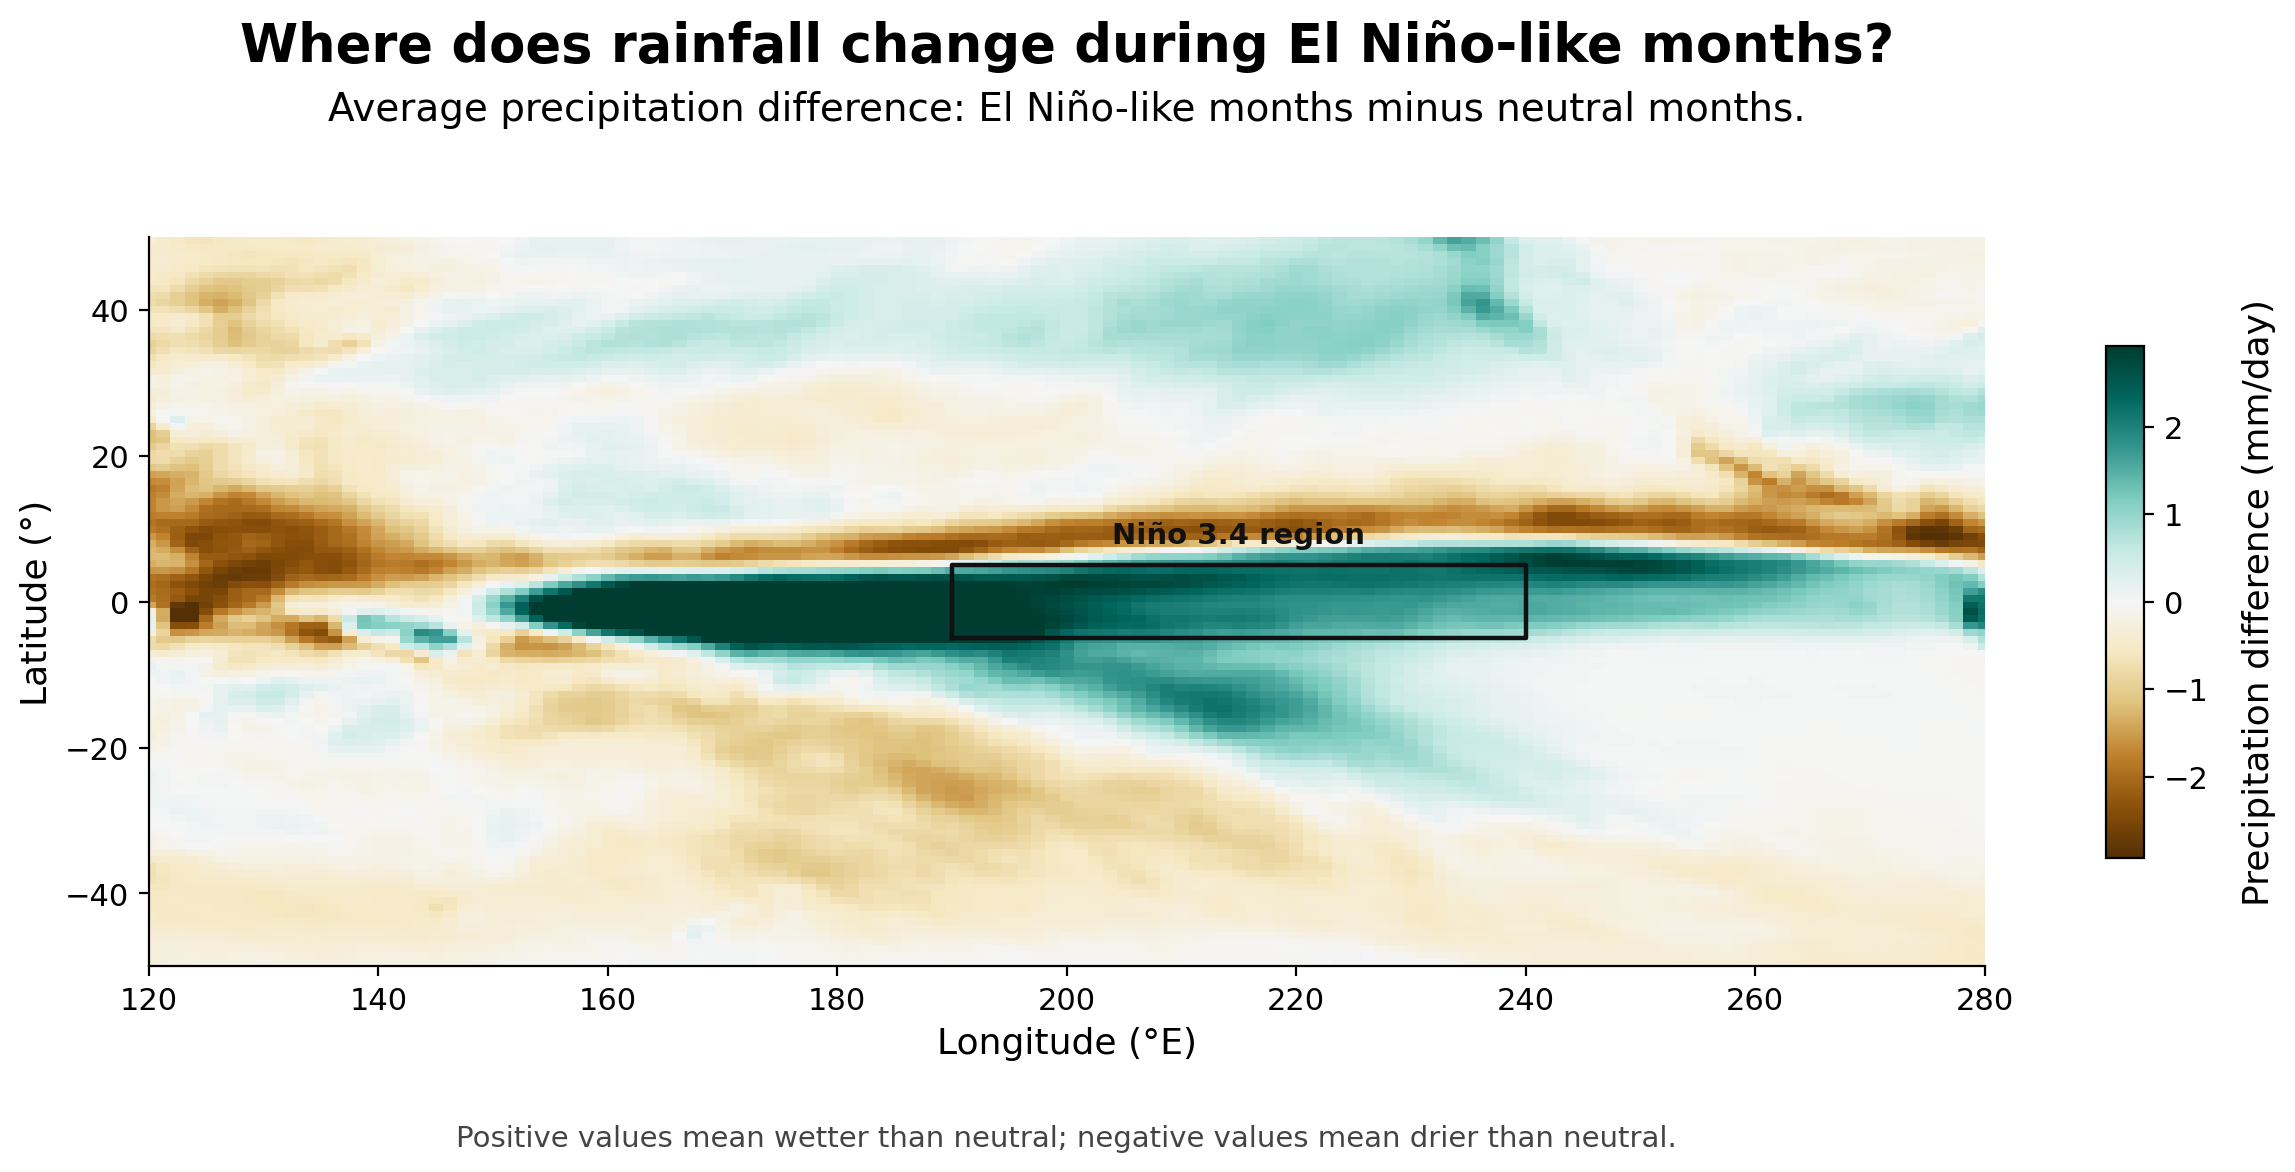

Saved static proposal figure to sancho_syquia_precipitation.png


In [34]:
pr_el, pr_neutral, pr_diff = composite_difference(ds_pr, "pr")

FIG_SIZE = (13.5, 6.4)
TITLE_SIZE = 19
SUBTITLE_SIZE = 14
AXIS_LABEL_SIZE = 13
TICK_LABEL_SIZE = 11
COLORBAR_LABEL_SIZE = 13
CAPTION_SIZE = 10.5


def plot_precipitation_difference(da, filename="sancho_syquia_precipitation.png"):
    data = pacific_view(da)
    vmax = float(np.nanpercentile(np.abs(data.values), 98))

    fig = plt.figure(figsize=FIG_SIZE)
    map_left, map_bottom, map_width, map_height = 0.16, 0.20, 0.68, 0.57
    map_center = map_left + map_width / 2
    ax = fig.add_axes([map_left, map_bottom, map_width, map_height])
    cax = fig.add_axes([0.885, 0.285, 0.014, 0.40])
    mesh = data.plot(
        ax=ax,
        x="lon",
        y="lat",
        cmap="BrBG",
        vmin=-vmax,
        vmax=vmax,
        add_colorbar=False,
    )

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Precipitation difference (mm/day)", fontsize=COLORBAR_LABEL_SIZE, labelpad=12)
    cbar.ax.tick_params(labelsize=TICK_LABEL_SIZE)

    fig.text(map_center, 0.94, "Where does rainfall change during El Niño-like months?", ha="center", va="top", fontsize=TITLE_SIZE, weight="bold")
    fig.text(map_center, 0.885, "Average precipitation difference: El Niño-like months minus neutral months.", ha="center", va="top", fontsize=SUBTITLE_SIZE)
    ax.set_xlabel("Longitude (°E)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Latitude (°)", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(labelsize=TICK_LABEL_SIZE)

    # Niño 3.4 classification region: 5S-5N, 170W-120W / 190E-240E.
    ax.plot([190, 240, 240, 190, 190], [-5, -5, 5, 5, -5], color="#111111", lw=1.6)
    ax.text(215, 8, "Niño 3.4 region", color="#111111", fontsize=10.5, weight="bold", ha="center")

    ax.set_xlim(120, 280)
    ax.set_ylim(-50, 50)
    fig.text(
        map_center,
        0.055,
        "Positive values mean wetter than neutral; negative values mean drier than neutral.",
        ha="center",
        va="bottom",
        fontsize=CAPTION_SIZE,
        color="#444444",
    )
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved static proposal figure to {filename}")


plot_precipitation_difference(pr_diff)


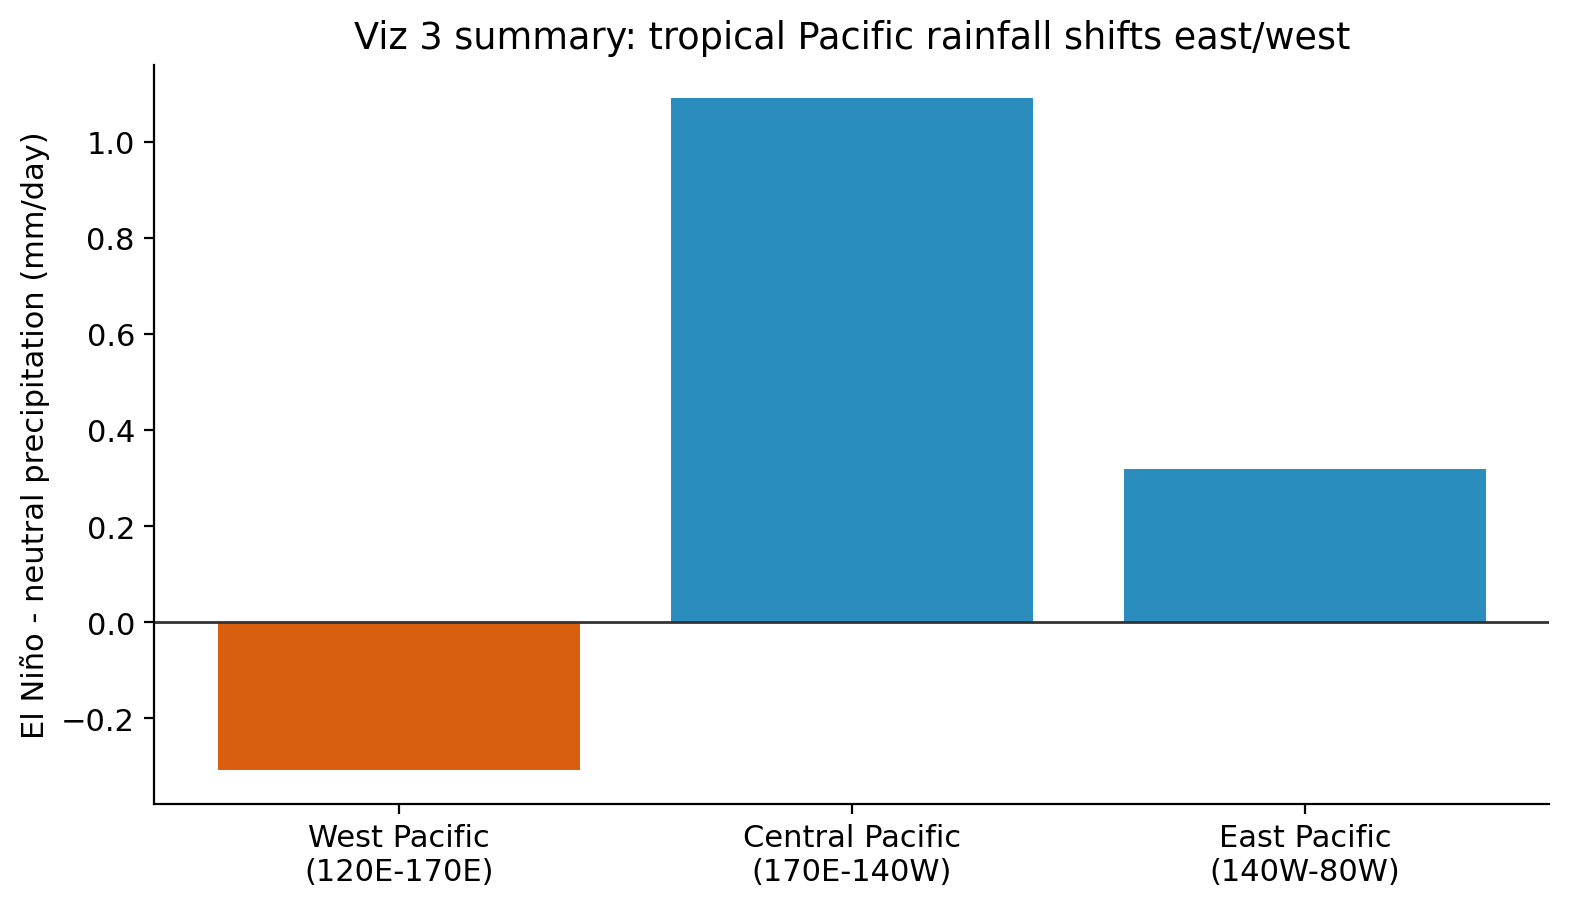

,region,value
0,West Pacific\n(120E-170E),-0.308240
1,Central Pacific\n(170E-140W),1.090250
2,East Pacific\n(140W-80W),0.318131


In [35]:
# Simple regional summary for proposal discussion.
regions = {
    "West Pacific\n(120E-170E)": {"lon": slice(120, 170), "lat": slice(-15, 15)},
    "Central Pacific\n(170E-140W)": {"lon": slice(170, 220), "lat": slice(-15, 15)},
    "East Pacific\n(140W-80W)": {"lon": slice(220, 280), "lat": slice(-15, 15)},
}

def regional_means(da):
    rows = []
    for name, bounds in regions.items():
        region = da.sel(lon=bounds["lon"], lat=bounds["lat"])
        rows.append({"region": name, "value": float(area_weighted_mean_latlon(region))})
    return pd.DataFrame(rows)

pr_region = regional_means(pr_diff)

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ["#2b8cbe" if v > 0 else "#d95f0e" for v in pr_region["value"]]
ax.bar(pr_region["region"], pr_region["value"], color=colors)
ax.axhline(0, color="#333333", lw=1)
ax.set_title("Viz 3 summary: tropical Pacific rainfall shifts east/west")
ax.set_ylabel("El Niño - neutral precipitation (mm/day)")
plt.show()

pr_region

## Viz 4. Cloud cover comparison during El Niño-like months

Variable: `clt`, total cloud cover percentage. This complements precipitation because cloud cover can show atmospheric circulation changes even where rainfall changes are smaller.

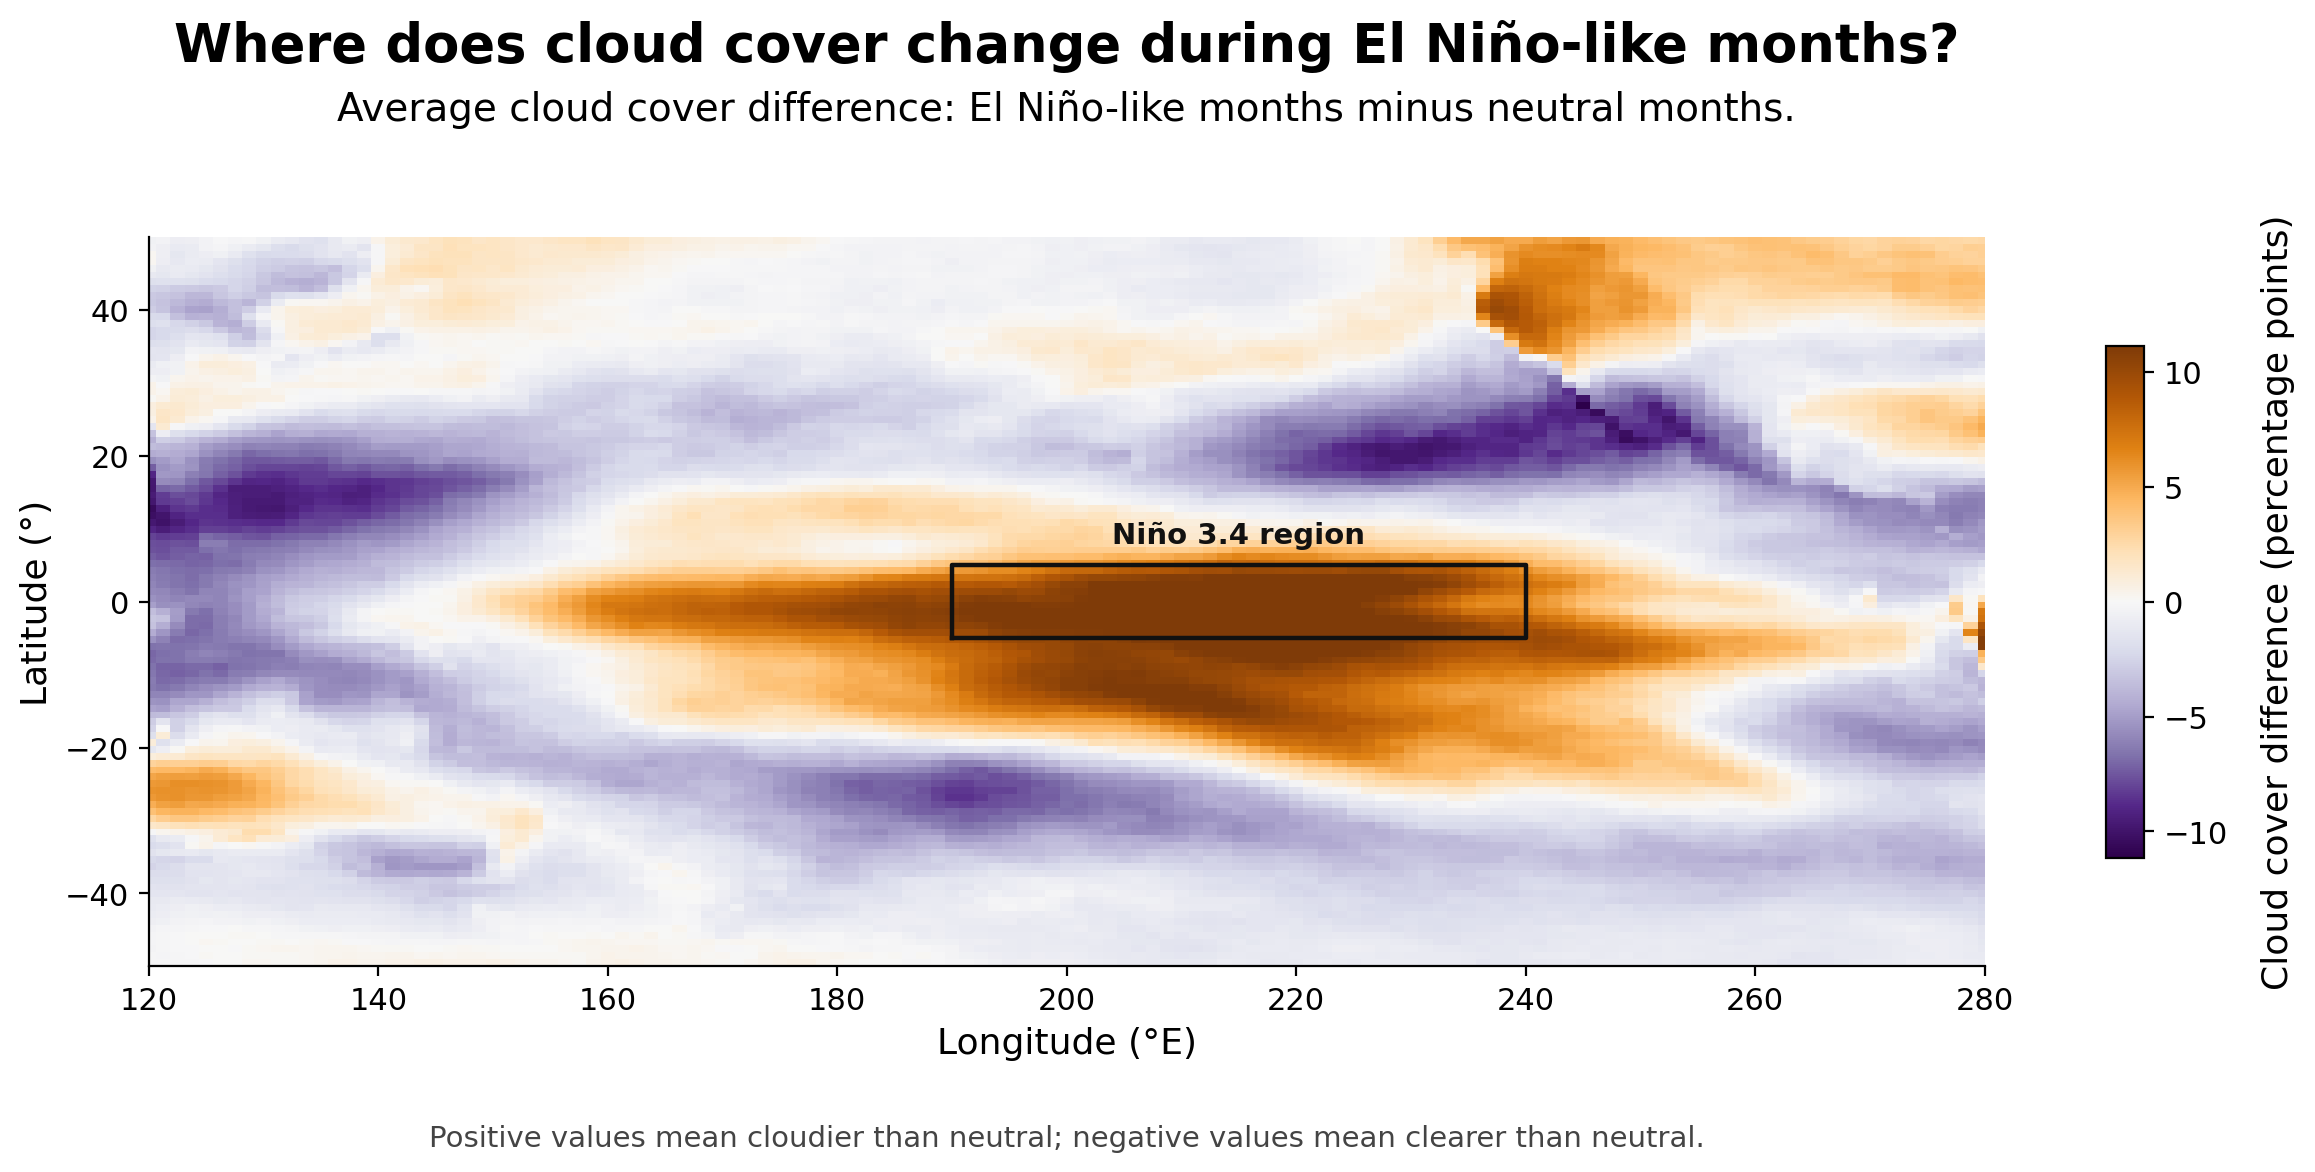

Saved static proposal figure to sancho_syquia_cloud_cover.png


In [36]:
clt_el, clt_neutral, clt_diff = composite_difference(ds_clt, "clt")

FIG_SIZE = (13.5, 6.4)
TITLE_SIZE = 19
SUBTITLE_SIZE = 14
AXIS_LABEL_SIZE = 13
TICK_LABEL_SIZE = 11
COLORBAR_LABEL_SIZE = 13
CAPTION_SIZE = 10.5


def plot_cloud_cover_difference(da, filename="sancho_syquia_cloud_cover.png"):
    data = pacific_view(da)
    vmax = float(np.nanpercentile(np.abs(data.values), 98))

    fig = plt.figure(figsize=FIG_SIZE)
    map_left, map_bottom, map_width, map_height = 0.16, 0.20, 0.68, 0.57
    map_center = map_left + map_width / 2
    ax = fig.add_axes([map_left, map_bottom, map_width, map_height])
    cax = fig.add_axes([0.885, 0.285, 0.014, 0.40])
    mesh = data.plot(
        ax=ax,
        x="lon",
        y="lat",
        cmap="PuOr_r",
        vmin=-vmax,
        vmax=vmax,
        add_colorbar=False,
    )

    cbar = fig.colorbar(mesh, cax=cax)
    cbar.set_label("Cloud cover difference (percentage points)", fontsize=COLORBAR_LABEL_SIZE, labelpad=12)
    cbar.ax.tick_params(labelsize=TICK_LABEL_SIZE)

    fig.text(map_center, 0.94, "Where does cloud cover change during El Niño-like months?", ha="center", va="top", fontsize=TITLE_SIZE, weight="bold")
    fig.text(map_center, 0.885, "Average cloud cover difference: El Niño-like months minus neutral months.", ha="center", va="top", fontsize=SUBTITLE_SIZE)
    ax.set_xlabel("Longitude (°E)", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Latitude (°)", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(labelsize=TICK_LABEL_SIZE)

    # Niño 3.4 classification region: 5S-5N, 170W-120W / 190E-240E.
    ax.plot([190, 240, 240, 190, 190], [-5, -5, 5, 5, -5], color="#111111", lw=1.6)
    ax.text(215, 8, "Niño 3.4 region", color="#111111", fontsize=10.5, weight="bold", ha="center")

    ax.set_xlim(120, 280)
    ax.set_ylim(-50, 50)
    fig.text(
        map_center,
        0.055,
        "Positive values mean cloudier than neutral; negative values mean clearer than neutral.",
        ha="center",
        va="bottom",
        fontsize=CAPTION_SIZE,
        color="#444444",
    )
    fig.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved static proposal figure to {filename}")


plot_cloud_cover_difference(clt_diff)


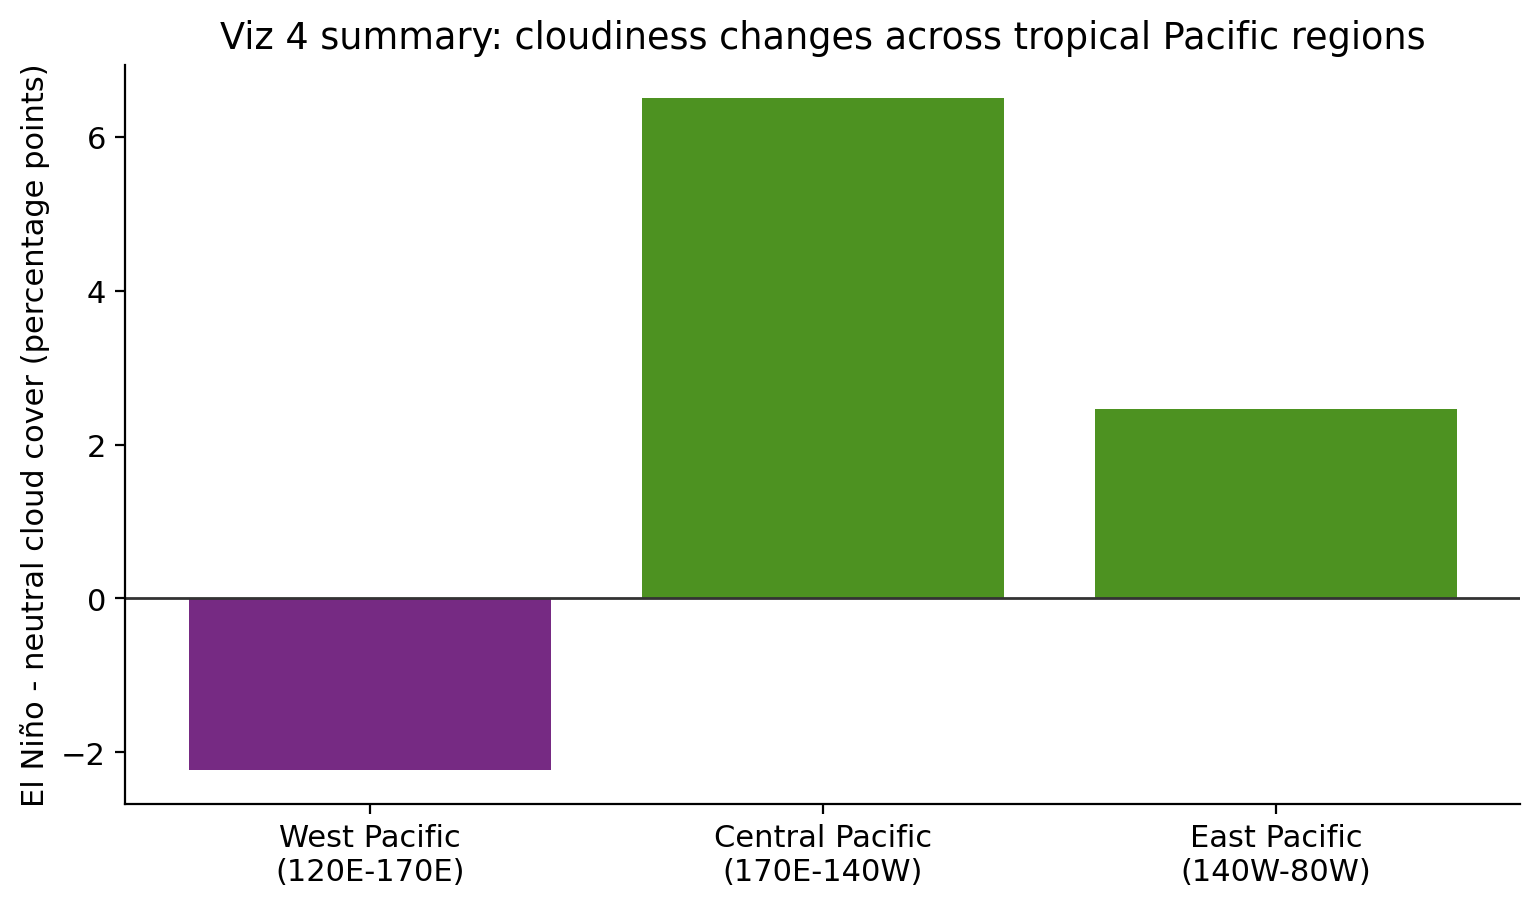

,region,value
0,West Pacific\n(120E-170E),-2.235733
1,Central Pacific\n(170E-140W),6.502921
2,East Pacific\n(140W-80W),2.462129


In [37]:
clt_region = regional_means(clt_diff)

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = ["#4d9221" if v > 0 else "#762a83" for v in clt_region["value"]]
ax.bar(clt_region["region"], clt_region["value"], color=colors)
ax.axhline(0, color="#333333", lw=1)
ax.set_title("Viz 4 summary: cloudiness changes across tropical Pacific regions")
ax.set_ylabel("El Niño - neutral cloud cover (percentage points)")
plt.show()

clt_region

## Proposal notes

The overall question is appropriate for DSC 106 because it is concrete, visual, and naturally interactive: readers can move between warm/cool/neutral Pacific phases and see ocean-atmosphere patterns change across space. A slightly stronger final wording would be: **How do El Niño-like warm Pacific months reorganize rainfall, cloud cover, and surface ocean conditions across the tropical Pacific?**

For the proposal, Viz 3 and Viz 4 work well because they connect the ocean trigger (`tos`) to visible weather outcomes (`pr` and `clt`). The final interactive version could let the reader brush months on the Niño 3.4 timeline and watch these maps update, which directly supports an explorable explanation rather than a static report.